In [12]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import torchvision
import torchvision.transforms as transforms
# from torchvision.models import resnet50, ResNet50_Weight
from data_utils.cub2011 import Cub2011
import os
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import ast
from functorch import jvp, grad, vjp
from cg_batch import cg_batch
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

import pytorch_influence_functions as ptif
from copy import deepcopy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
data_path = "/tmp2/chhavi/"
dataset = "pet"
input_size=2048
num_classes=37

In [14]:
loaded_df_train = pd.read_csv(f'{data_path}resnet50_features/train_features_labels.csv')

# Convert DataFrame columns back to tensors
train_feat_loaded_df = loaded_df_train['features'].apply(ast.literal_eval) 
train_feat_loaded_tensor = torch.tensor(train_feat_loaded_df.tolist())

train_labels_loaded_tensor = torch.tensor(loaded_df_train['gt_labels'].tolist())

# Reshape tensors to their original sizes
n_rows, n_cols = loaded_df_train.shape[0], len(loaded_df_train.iloc[0].features.split(','))
train_x_feat_tensor = train_feat_loaded_tensor.view(n_rows, n_cols)
train_labels_tensor = train_labels_loaded_tensor.view(n_rows)

In [15]:
loaded_df_test = pd.read_csv(f'{data_path}resnet50_features/test_features_labels.csv')

# Convert DataFrame columns back to tensors
test_feat_loaded_df = loaded_df_test['features'].apply(ast.literal_eval) 
test_feat_loaded_tensor = torch.tensor(test_feat_loaded_df.tolist())

test_labels_loaded_tensor = torch.tensor(loaded_df_test['gt_labels'].tolist())

# Reshape tensors to their original sizes
n_rows, n_cols = loaded_df_test.shape[0], len(loaded_df_test.iloc[0].features.split(','))
test_x_feat_tensor = test_feat_loaded_tensor.view(n_rows, n_cols)
test_labels_tensor = test_labels_loaded_tensor.view(n_rows)

In [16]:
# Define your model
class LinearClassifier(nn.Module):
    def __init__(self, input_size=2048, num_classes=37):
        super(LinearClassifier, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.linear(x)

In [17]:
# Standardize the data
mean = train_x_feat_tensor.mean(dim=0)
std = train_x_feat_tensor.std(dim=0)
train_std_features = (train_x_feat_tensor - mean) / std

# Move data to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_std_features = train_std_features.to(device)
train_labels = train_labels_tensor.to(device)

# Create a TensorDataset
train_dataset = TensorDataset(train_std_features, train_labels)

# Create a DataLoader for batch training
batch_size = 64  # You can adjust the batch size as needed
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_dataloader_noshuffle = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
model_path = f'{data_path}resnet50_features/linear_classifier_{dataset}.pt'

input_size = train_x_feat_tensor.shape[1]
num_classes = len(torch.unique(train_labels_tensor))
print(input_size, num_classes)
# Instantiate the model and move it to GPU if available
model = LinearClassifier(input_size, num_classes).to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

2048 37


In [18]:
model = LinearClassifier()
model.to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

LinearClassifier(
  (linear): Linear(in_features=2048, out_features=37, bias=True)
)

In [19]:
# After training, you can use the model for predictions
# For example, if you have a test feature tensor called test_features:
# Move test data to GPU if available
test_std_features = (test_x_feat_tensor - mean)/std
test_std_features = test_std_features.to(device)
test_labels = test_labels_tensor.to(device)

test_dataset = TensorDataset(test_std_features, test_labels)
test_dataloader_noshuffle = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

test_outputs = model(test_std_features)
predicted_labels = torch.argmax(test_outputs, dim=1)

# Calculate test accuracy
test_accuracy = torch.sum(predicted_labels == test_labels).item() / len(test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 92.07%


In [20]:
for name, param in model.named_parameters():
    print(f"Parameter name: {name}, Size: {param.size()}")
    print(f"Parameter values: {param}")

Parameter name: linear.weight, Size: torch.Size([37, 2048])
Parameter values: Parameter containing:
tensor([[ 0.0294,  0.0083, -0.0272,  ..., -0.0227, -0.0165, -0.0101],
        [ 0.0114,  0.0332,  0.0339,  ...,  0.0139, -0.0146,  0.0141],
        [-0.0231,  0.0038, -0.0052,  ..., -0.0236,  0.0196, -0.0187],
        ...,
        [-0.0177,  0.0512, -0.0218,  ...,  0.0424, -0.0095, -0.0283],
        [-0.0097,  0.0225, -0.0211,  ..., -0.0129, -0.0326,  0.0160],
        [ 0.0172,  0.0132, -0.0053,  ..., -0.0131, -0.0002,  0.0356]],
       device='cuda:0', requires_grad=True)
Parameter name: linear.bias, Size: torch.Size([37])
Parameter values: Parameter containing:
tensor([-0.0013, -0.0111, -0.0014, -0.0139, -0.0189,  0.0171, -0.0096,  0.0176,
         0.0281,  0.0018, -0.0103,  0.0012,  0.0005,  0.0196,  0.0213,  0.0062,
         0.0131, -0.0056, -0.0100,  0.0179, -0.0017, -0.0031, -0.0054,  0.0176,
         0.0126, -0.0061, -0.0021,  0.0129,  0.0104, -0.0199, -0.0187,  0.0215,
        -0

In [21]:
X_test = test_std_features
X_train = train_std_features
Y_test = test_labels
Y_train = train_labels

In [23]:
torch.save((X_train, Y_train), "pet_train.pt")
torch.save((X_test, Y_test), "pet_test.pt")

In [11]:
model.zero_grad()
batch_size=1024
recursion_depth=1000000
scale = 25
damp = 0.01 * scale

# def influence_forward_batch(model):
# inf = torch.zeros(len(Y_train)).cuda()

In [12]:
def inf_forward_only(model, X_train, Y_train, X_test, Y_test, return_cache=True, damp=0.25, scale=25):
    model_static = deepcopy(model)
    model_static.zero_grad()
    H_inv_g_test = ptif.s_test_sample(model_static, X_test, Y_test, train_dataloader_noshuffle, gpu=1, batch_size=batch_size, recursion_depth=recursion_depth, damp=damp, scale=scale)
    model.zero_grad()
    g_train_all = [ptif.grad_z(X_train[i].unsqueeze(0), Y_train[i].unsqueeze(0), model, gpu=0, loss_func="cross_entropy", create_graph=False) for i in range(len(Y_train))]
    inf_forward = torch.zeros(len(Y_train)).cuda()
    for i in range(len(Y_train)): 
        inf_forward[i] = -torch.cat([(_H_inv_g_test * _g_train).sum().unsqueeze(0) for _H_inv_g_test, _g_train in zip(H_inv_g_test, g_train_all[i])]).sum()
    del model_static
    if return_cache:
        return inf_forward, H_inv_g_test
    else:
        return inf_forward
    
def hvp(model, X_train, Y_train, v, loss_func="cross_entropy", create_graph=True, damp=0):
    names = [name for name, p in list(model.named_parameters())]
    params = tuple(model.parameters())
    
    model_static = deepcopy(model)
    ptif.make_functional(model_static)
    
    def f(*new_params):
        ptif.load_weights(model_static, names, new_params)
        out = model_static(X_train)
        loss = ptif.calc_loss(out, Y_train, loss_func=loss_func)
        loss += 0.5 * damp * sum((param * param).sum() for param in new_params)
        return loss

    hv = torch.autograd.functional.hvp(f, params, tuple(v), strict=True, create_graph=create_graph)[1]
#     ptif.load_weights(model, names, params, as_params=True)
    return hv
    
def inf_loss(model, X_train, Y_train, X_test, Y_test, coeff, H_inv_g_test=None, damp=0.25, scale=25):
    model_static = deepcopy(model)
    model_static.zero_grad()
    if H_inv_g_test is None:
        H_inv_g_test = ptif.s_test_sample(model_static, X_test, Y_test, train_dataloader_noshuffle, gpu=1, batch_size=batch_size, recursion_depth=recursion_depth, damp=damp, scale=scale)
    del model_static
    model_static = deepcopy(model)
    model_static.zero_grad()
    H_inv_g_train_coeff = ptif.s_test_sample(model_static, X_train, Y_train, train_dataloader_noshuffle, gpu=1, batch_size=batch_size, recursion_depth=recursion_depth, coeff=coeff, damp=damp, scale=scale)
    del model_static

    g_train_coeff = ptif.grad_z(X_train, Y_train, model, gpu=0, loss_func="cross_entropy", create_graph=True, coeff=coeff)
    g_test = ptif.grad_z(X_test, Y_test, model, gpu=0, loss_func="cross_entropy", create_graph=True, coeff=None)
    g_test_back = hvp(model, X_train, Y_train, H_inv_g_test, create_graph=True, damp=damp)

    
    inf_loss_1 = -torch.cat([(_H_inv_g_test * _g_train).sum().unsqueeze(0) for _H_inv_g_test, _g_train in zip(H_inv_g_test, g_train_coeff)]).sum()
    inf_loss_2 = -torch.cat([(_H_inv_g_train_coeff * _g_test).sum().unsqueeze(0) for _H_inv_g_train_coeff, _g_test in zip(H_inv_g_train_coeff, g_test)]).sum()
    inf_loss_3 = -torch.cat([(_H_inv_g_train_coeff * _g_test).sum().unsqueeze(0) for _H_inv_g_train_coeff, _g_test in zip(H_inv_g_train_coeff, g_test_back)]).sum()
    return inf_loss_1 + inf_loss_2 - inf_loss_3
#     return inf_loss_1  inf_loss_2 + inf_loss_3

In [13]:
inf_forward, H_inv_g_test = inf_forward_only(model, X_train, Y_train, X_test, Y_test, damp=damp, scale=scale)
coeff = torch.ones([len(Y_train)]).cuda() / len(Y_train)
model_static = deepcopy(model)
model_static.zero_grad()
H_inv_g_train_coeff = ptif.s_test_sample(model_static, X_train, Y_train, train_dataloader_noshuffle, gpu=1, batch_size=batch_size, recursion_depth=recursion_depth, coeff=coeff, damp=damp, scale=scale)
del model_static

In [16]:
model.zero_grad()

g_train_coeff = ptif.grad_z(X_train, Y_train, model, gpu=0, loss_func="cross_entropy", create_graph=True, coeff=coeff)
g_test = ptif.grad_z(X_test, Y_test, model, gpu=0, loss_func="cross_entropy", create_graph=True, coeff=None)

# g_train_coeff[0].sum().backward()
inf_loss_1 = -torch.cat([(_H_inv_g_test * _g_train).sum().unsqueeze(0) for _H_inv_g_test, _g_train in zip(H_inv_g_test, g_train_coeff)]).sum()
inf_loss_2 = -torch.cat([(_H_inv_g_train_coeff * _g_test).sum().unsqueeze(0) for _H_inv_g_train_coeff, _g_test in zip(H_inv_g_train_coeff, g_test)]).sum()


g_test_back = hvp(model, X_train, Y_train, H_inv_g_test, create_graph=True, damp=damp)
inf_loss_3 = -torch.cat([(_H_inv_g_train_coeff * _g_test).sum().unsqueeze(0) for _H_inv_g_train_coeff, _g_test in zip(H_inv_g_train_coeff, g_test_back)]).sum()
loss = inf_loss_1 + inf_loss_2# + inf_loss_3
loss.backward()

print(model.linear.weight.grad)

print(g_train_coeff[0].requires_grad)
print(g_test[0].requires_grad)

inf_loss_1.backward()
print(model.linear.weight.grad)

tensor([[-4.8931e-04, -7.0744e-04, -1.7140e-04,  ..., -4.1221e-05,
         -3.0034e-04, -8.0668e-04],
        [ 2.2597e-03, -4.7312e-03, -1.3040e-03,  ..., -2.8025e-04,
         -5.7874e-04, -7.2715e-04],
        [-4.3791e-03,  6.1912e-03,  1.0865e-03,  ...,  1.0365e-03,
          4.1667e-03, -7.8492e-05],
        ...,
        [ 1.8882e-03, -1.7875e-03,  2.1454e-04,  ..., -7.2267e-04,
         -2.9894e-03,  8.8594e-04],
        [-7.9399e-05,  9.8166e-05,  7.1588e-06,  ...,  1.0259e-04,
         -1.8831e-05,  8.1063e-05],
        [ 1.7622e-04,  1.9951e-04, -1.3934e-04,  ...,  4.6310e-04,
          3.4426e-04,  3.6792e-04]], device='cuda:0')
True
True


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [17]:
def get_acc(model, X_test, Y_test):
    outputs = model(X_test)
    Y_pred = torch.argmax(outputs, dim=1)
    acc = torch.sum(Y_pred == Y_test).item() / len(Y_test)
    return acc

def apply_diff_to_model(delta_theta, model):
    for para, _delta_theta in zip(model.parameters(), delta_theta):
        para.data += _delta_theta
    return model

def clip_model(model, model_origin, original_theta_norm, norm_bound):
    delta_theta = [para.data - para_origin.data for para, para_origin in zip(model.parameters(), model_origin.parameters())]
    delta_theta_norm = torch.sqrt(sum(_delta_theta.norm() ** 2 for _delta_theta in delta_theta))
    if delta_theta_norm > norm_bound:
        delta_theta = [_delta_theta * norm_bound / delta_theta_norm for _delta_theta in delta_theta]
        for para, para_origin, _delta_theta in zip(model.parameters(), model_origin.parameters(), delta_theta):
            para.data = para_origin.data + _delta_theta
    return model

def targeted_attack(targeted_index, model, targeted_K=10, eps=0.1, total_iter=1000, setup="", lr=0.0001):    
    model_origin = model
    model = deepcopy(model_origin)
    delta_theta = [torch.randn(para.shape).to(device) for para in model.parameters()]
    model = apply_diff_to_model(delta_theta, model)
    if "L2" in setup:
        original_theta_norm = torch.sqrt(sum(para.data.norm() ** 2 for para in model_origin.parameters()))
        norm_bound = eps * original_theta_norm
        model = clip_model(model, model_origin, original_theta_norm, norm_bound)
    
    for para in model.parameters():
        para.requires_grad = True
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #, momentum=0.9) #LEARNING RATE IS IMPORTANT 0.01 FOR L2, 0.001 for cos
    
    for it in range(total_iter):
        optimizer.zero_grad()
                    
        acc = get_acc(model, X_test, Y_test)
        
        cur_inf_each_train, H_inv_g_test = inf_forward_only(model, X_train, Y_train, X_test, Y_test, return_cache=True, damp=0.25, scale=25)
        
        cur_rank = torch.argsort(cur_inf_each_train, descending=True) #[i], the id of rank i
        cur_rank_id = torch.argsort(cur_rank)
        #what we want: [i], the rank of id'th data; 
        
        cur_targeted_rank = cur_rank_id[targeted_index]
        
        if cur_targeted_rank < targeted_K:
            break
        
        if "margin" in setup:
            higher_data_id = cur_rank[:cur_targeted_rank]
            coeff = torch.zeros(len(Y_train)).cuda()
            coeff[targeted_index] = -1
            coeff[higher_data_id] = 1.0 / len(higher_data_id)
            loss = inf_loss(model, X_train, Y_train, X_test, Y_test, coeff, H_inv_g_test)
                
#         print(1, model.linear.bias[0], model.linear.bias.grad)
        loss.backward()
#         if it%100 == 0:
        print(it, loss.item(), cur_targeted_rank.item(), acc)
    
        if it == int(0.5 * total_iter):
            for g in optimizer.param_groups:
                g['lr'] = g['lr'] * 0.1
#         elif it == int(0.25 * total_iter):
#             for g in optim.param_groups:
#                 g['lr'] = g['lr'] * 0.1
#         print(2, model.linear.bias[0], model.linear.bias.grad)
#         for g in optimizer.param_groups:
#             print(2.5, g["params"][1][0], g["params"][1].grad)
                
                
        optimizer.step()
        
#         print(3, model.linear.bias[0], model.linear.bias.grad)
        
        
        if "L2" in setup:
            clip_model(model, model_origin, original_theta_norm, norm_bound)
#         print(4, model.linear.bias[0], model.linear.bias.grad)
        
    return cur_targeted_rank, acc

In [18]:
original_inf_each_train_batch = inf_forward_only(model, X_train, Y_train, X_test, Y_test, False)

original_sorted_index_batch = torch.argsort(original_inf_each_train_batch, descending=True)
# Sort the vector in descending order
original_sorted_vector_batch = original_inf_each_train_batch[original_sorted_index_batch]
original_rank_id = torch.argsort(original_sorted_index_batch)

In [ ]:
eps_list_list = [
    [0.1, 0.3, 0.5, 1.0],
]

setup_list = [
    "L2_margin", 
] #, , "closerinit_cos"] #

lr_list = [
    0.01,
]

dataset = "pet"

total_iter = 100
num_seed = 1
num_data = 10
for targeted_K in [10, 3]:
    torch.manual_seed(0)
    selected_id = original_sorted_index_batch[targeted_K:][torch.randperm(len(Y_train)-targeted_K)][:num_data]
    pre_attack_rank = original_rank_id[selected_id]
    post_acc_all_eps = []
    post_attack_rank_all_eps = []
    for eps_list, setup in zip(eps_list_list, setup_list): # #"L2", 
        for eps in eps_list:
            print(f"gd_attack_checkpoint/gd_targeted_attack_multiclass_{dataset}_{targeted_K}_{setup}_{eps}_{total_iter}_{num_data}_{num_seed}.pt")
            if os.path.exists(f"gd_attack_checkpoint/gd_targeted_attack_multiclass_{dataset}_{targeted_K}_{setup}_{eps}_{total_iter}_{num_data}_{num_seed}.pt"):
                print(setup, eps)
                continue
            post_acc = []
            post_attack_rank = []
            for data_id in tqdm(selected_id):
                best_rank = 1000
                best_acc = 0
                for seed in range(num_seed):
                    for lr in lr_list:
                        cur_targeted_rank, acc = targeted_attack(data_id, model, targeted_K=targeted_K, eps=eps, total_iter=total_iter, setup=setup, lr=lr)
                        if best_rank < targeted_K:
                            if cur_targeted_rank < targeted_K:
                                if acc > best_acc:
                                    best_rank, best_acc = cur_targeted_rank, acc
                        else:
                            if cur_targeted_rank < best_rank:
                                best_rank, best_acc = cur_targeted_rank, acc
                            
                post_attack_rank.append(best_rank)
                post_acc.append(best_acc)

            post_acc_all_eps.append(post_acc)
            post_attack_rank_all_eps.append(post_attack_rank)
            print(targeted_K, setup, eps, torch.tensor(post_acc).float()[torch.tensor(post_attack_rank).float() < targeted_K].mean(), (torch.tensor(post_attack_rank).float() < targeted_K).float().mean())

            torch.save((post_acc, post_attack_rank), f"gd_attack_checkpoint/gd_targeted_attack_multiclass_{dataset}_{targeted_K}_{setup}_{eps}_{total_iter}_{num_seed}.pt")
    


  0%|          | 0/10 [00:00<?, ?it/s]

gd_attack_checkpoint/gd_targeted_attack_multiclass_pet_10_L2_margin_0.1_100_1.pt
0 0.03525017201900482 1294 0.9215044971381848
1 0.019453339278697968 544 0.8999727446170619
2 0.029076360166072845 66 0.8937040065412919
3 0.06814391911029816 18 0.896429544835105
4 0.03811946511268616 87 0.8931588988825293
5 0.039237767457962036 14 0.8920686835650041


 10%|█         | 1/10 [02:07<19:07, 127.45s/it]

0 0.018483763560652733 2609 0.9204142818206595
1 0.007768847048282623 1648 0.9029708367402562
2 0.004642656072974205 1589 0.8926137912237667
3 0.0036910208873450756 1638 0.8896156991005724
4 0.0032730819657444954 1662 0.8907059144180975
5 0.003013434587046504 1654 0.8893431452711911
6 0.0028661279939115047 1645 0.8926137912237667
7 0.0026581110432744026 1616 0.890160806759335
8 0.0026547263842076063 1549 0.8882529299536659
9 0.0025019121821969748 1577 0.8863450531479967
10 0.0025164864491671324 1537 0.8852548378304715
11 0.0024818978272378445 1528 0.8863450531479967
12 0.002553954953327775 1535 0.886617606977378
13 0.002397105796262622 1526 0.884709730171709
14 0.0023748758248984814 1508 0.8833469610248024
15 0.002393363043665886 1500 0.883892068683565
16 0.002432785928249359 1483 0.8830744071954211
17 0.002405527513474226 1484 0.8852548378304715
18 0.0024258263874799013 1511 0.8844371763423277
19 0.002523984294384718 1444 0.883892068683565
20 0.0024166943039745092 1472 0.8836195148541

 20%|██        | 2/10 [34:34<2:39:40, 1197.51s/it]

...

0 0.018541380763053894 2820 0.9217770509675661
1 0.008156966418027878 1425 0.8977923139820114
2 0.004834781400859356 1388 0.8871627146361406
3 0.003884413745254278 1406 0.8817116380485146
4 0.0034291076008230448 1421 0.8814390842191333
5 0.0031530873384326696 1412 0.8781684382665577
6 0.0029937406070530415 1429 0.8765331152902698
7 0.002830475103110075 1407 0.8754428999727446
8 0.002777626970782876 1451 0.8808939765603707
9 0.002739222953096032 1464 0.8800763150722267
10 0.0025541253853589296 1438 0.8787135459253202
11 0.0026017031632363796 1404 0.8768056691196511
12 0.002845614217221737 1230 0.8762605614608885
13 0.0026383334770798683 1359 0.8746252384846007
14 0.0030753291212022305 1110 0.8757154538021259
15 0.0034737433306872845 1001 0.8746252384846007
16 0.0038655013777315617 920 0.8740801308258381
17 0.0034123966470360756 902 0.8768056691196511
18 0.004469387233257294 839 0.8787135459253202
19 0.0045811478048563 754 0.8792586535840828
20 0.00507506774738431 659 0.8789860997547015


 40%|████      | 4/10 [46:56<1:07:23, 673.90s/it]

0 0.07528962939977646 412 0.9209593894794222
1 0.039059463888406754 95 0.8947942218588171


 50%|█████     | 5/10 [47:45<37:23, 448.75s/it]  

0 0.019246062263846397 2448 0.9212319433088035
1 0.007305950857698917 1462 0.9024257290814935
2 0.004793452098965645 1442 0.8920686835650041
3 0.004170688800513744 1336 0.8887980376124285
4 0.0033021073322743177 1402 0.8871627146361406
5 0.0032562611158937216 1362 0.883892068683565
6 0.002934926887974143 1381 0.8828018533660398
7 0.002945092972368002 1324 0.880348868901608
8 0.0030500374268740416 1225 0.8789860997547015
9 0.002783424686640501 1303 0.8789860997547015
10 0.0026434040628373623 1350 0.8776233306077951
11 0.0027888058684766293 1238 0.8781684382665577
12 0.0030315641779452562 1192 0.8770782229490325
13 0.0030078382696956396 1160 0.8768056691196511
14 0.002917221048846841 1142 0.8765331152902698
15 0.0029900679364800453 1133 0.8778958844371764
16 0.003226063447073102 1082 0.8773507767784138
17 0.0032813644502311945 1024 0.8768056691196511
18 0.0032947154249995947 968 0.8751703461433633
19 0.0036243062932044268 891 0.8746252384846007
20 0.0042519401758909225 750 0.874352684655

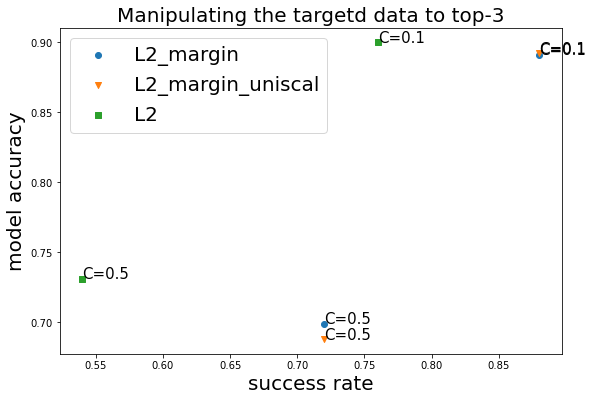

In [24]:
import matplotlib.pyplot as plt

COLOR_S = "#69b3a2"
COLOR_A = "#3399e6"

fontsize = 20

dataset = "pet"
num_seed = 1

total_iter = 100
num_data = 100
#important!!!
computed_num_data = 50

eps_list_list = [
    [0.1, 0.5, 1.0],
    [0.1, 0.5, 1.0],
    [0.1, 0.5, 1.0],
]

setup_list = [
    "L2_margin", 
    "L2_margin_uniscal",
    "L2"
] #, , "closerinit_cos"] #

marker_list = ["o", "v", "s", "p"]
for targeted_K in [3]:
    fig, ax1 = plt.subplots(figsize=(9, 6))
    # ax2 = ax1.twinx()

    for setup, marker, eps_list in zip(setup_list, marker_list, eps_list_list):
        success_rate_list = []
        acc_success_list = []
        for eps in eps_list[:2]:
            checkpoint_name = f"gd_attack_checkpoint/gd_targeted_attack_multiclass_{dataset}_{targeted_K}_{setup}_{eps}_{num_data}_{total_iter}_{num_seed}_{0}.pt"
            (post_acc, post_attack_rank) = torch.load(checkpoint_name, map_location=torch.device('cpu'))
            post_acc = post_acc[:computed_num_data]
            post_attack_rank = post_attack_rank[:computed_num_data]
            post_attack_rank = torch.tensor(post_attack_rank).float()
            success_rate_list.append((post_attack_rank < targeted_K).float().mean())
            post_acc = torch.tensor(post_acc).float()
            acc_success_list.append(post_acc[post_attack_rank < targeted_K].mean())
#             break
        ax1.scatter(success_rate_list, acc_success_list, label=setup, marker=marker)
        for x, y, eps in zip(success_rate_list, acc_success_list, eps_list):
            ax1.annotate(f"C={eps}", (x, y), fontsize=15)
#             break
        
        
    #     ax1.tick_params(axis="y", labelcolor=COLOR_S)
    #     ax2.plot(eps_list, acc_success_list, color=COLOR_A, label=setup, marker=marker)
    #     ax2.tick_params(axis="y", labelcolor=COLOR_A)

    ax1.set_ylabel("model accuracy", fontsize=fontsize)
    # ax2.set_ylabel("accuracy", color=COLOR_A, fontsize=fontsize)

    ax1.set_xlabel("success rate", fontsize=fontsize)
    plt.legend(fontsize=fontsize)
    plt.title(f"Manipulating the targetd data to top-{targeted_K}", fontsize=fontsize)
    plt.show()